In [72]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [73]:
data_dir = "data"   # base folder - Changed to point to the downloaded dataset
img_size = (64, 64)        #resize all images to 64x64
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')] # Filter out non-directory files starting with '.'
print("Clases detectadas:", classes)

X = []
y = []

for label, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    print(f"Processing class: {folder}")
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path).convert("RGB")   #open image
            img = img.resize(img_size)             #resize
            arr = np.array(img).flatten() / 255.0  #flatten + normalize
            X.append(arr)
            y.append(label)
        except Exception as e: # Catch specific exception for better debugging
            print(f"Skipping file: {path} - Error: {e}")

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, "Labels:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

Clases detectadas: ['bicycle', 'no-bicycle']
Processing class: data/bicycle
Processing class: data/no-bicycle
Dataset shape: (945, 12288) Labels: (945,)


In [74]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [75]:
model1pred = model1.predict(X_test)
model1acc = accuracy_score(y_test, model1pred)
model1report = classification_report(y_test, model1pred)
model1conf = confusion_matrix(y_test, model1pred)
print("Accuracy:", model1acc)
print("Classification Report:\n", model1report)
print("Confusion Matrix:\n", model1conf)

Accuracy: 0.9154929577464789
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.59      0.66        39
           1       0.94      0.97      0.95       245

    accuracy                           0.92       284
   macro avg       0.84      0.78      0.80       284
weighted avg       0.91      0.92      0.91       284

Confusion Matrix:
 [[ 23  16]
 [  8 237]]


In [76]:
model2 = SVC(kernel="rbf", C=1.0, gamma="scale")
model2.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [77]:
model2pred = model2.predict(X_test)
model2acc = accuracy_score(y_test, model2pred)
model2report = classification_report(y_test, model2pred)
model2conf = confusion_matrix(y_test, model2pred)
print("Accuracy:", model2acc)
print("Classification Report:\n", model2report)
print("Confusion Matrix:\n", model2conf)

Accuracy: 0.9436619718309859
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.62      0.75        39
           1       0.94      1.00      0.97       245

    accuracy                           0.94       284
   macro avg       0.95      0.81      0.86       284
weighted avg       0.94      0.94      0.94       284

Confusion Matrix:
 [[ 24  15]
 [  1 244]]


In [78]:
# Add a KNN model, train, and evaluate
model3 = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")
model3.fit(X_train, y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [79]:
model3pred = model3.predict(X_test)
model3acc = accuracy_score(y_test, model3pred)
model3report = classification_report(y_test, model3pred)
model3conf = confusion_matrix(y_test, model3pred)
print("Accuracy:", model3acc)
print("Classification Report:\n", model3report)
print("Confusion Matrix:\n", model3conf)

Accuracy: 0.8697183098591549
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.79      0.63        39
           1       0.96      0.88      0.92       245

    accuracy                           0.87       284
   macro avg       0.74      0.84      0.77       284
weighted avg       0.90      0.87      0.88       284

Confusion Matrix:
 [[ 31   8]
 [ 29 216]]


In [80]:
# Decision Tree model: train and evaluate
model4 = DecisionTreeClassifier(random_state=42, max_depth=None, min_samples_split=2)
model4.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [81]:
model4pred = model4.predict(X_test)
model4acc = accuracy_score(y_test, model4pred)
model4report = classification_report(y_test, model4pred)
model4conf = confusion_matrix(y_test, model4pred)
print("Accuracy:", model4acc)
print("Classification Report:\n", model4report)
print("Confusion Matrix:\n", model4conf)

Accuracy: 0.8556338028169014
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.59      0.53        39
           1       0.93      0.90      0.91       245

    accuracy                           0.86       284
   macro avg       0.71      0.74      0.72       284
weighted avg       0.87      0.86      0.86       284

Confusion Matrix:
 [[ 23  16]
 [ 25 220]]


In [82]:
# Random Forest model: train and evaluate
model5 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model5.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
model5pred = model5.predict(X_test)
model5acc = accuracy_score(y_test, model5pred)
model5report = classification_report(y_test, model5pred)
model5conf = confusion_matrix(y_test, model5pred)
print("Accuracy:", model5acc)
print("Classification Report:\n", model5report)
print("Confusion Matrix:\n", model5conf)

Accuracy: 0.9190140845070423
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.44      0.60        39
           1       0.92      1.00      0.95       245

    accuracy                           0.92       284
   macro avg       0.93      0.72      0.78       284
weighted avg       0.92      0.92      0.91       284

Confusion Matrix:
 [[ 17  22]
 [  1 244]]


In [84]:
model6 = GradientBoostingClassifier(random_state=42)
model6.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [85]:
model6pred = model6.predict(X_test)
model6acc = accuracy_score(y_test, model6pred)
model6report = classification_report(y_test, model6pred)
model6conf = confusion_matrix(y_test, model6pred)
print("Accuracy:", model6acc)
print("Classification Report:\n", model6report)
print("Confusion Matrix:\n", model6conf)

Accuracy: 0.9366197183098591
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.67      0.74        39
           1       0.95      0.98      0.96       245

    accuracy                           0.94       284
   macro avg       0.89      0.82      0.85       284
weighted avg       0.93      0.94      0.93       284

Confusion Matrix:
 [[ 26  13]
 [  5 240]]


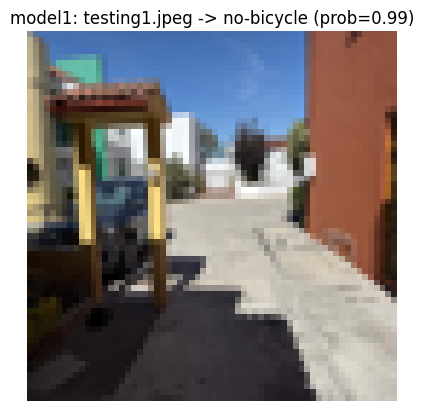

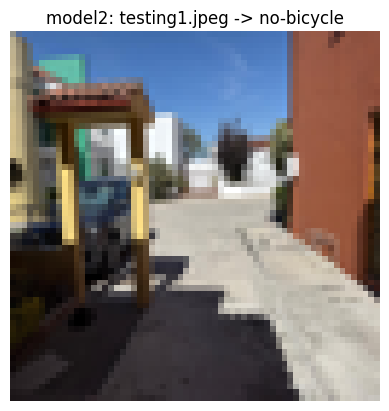

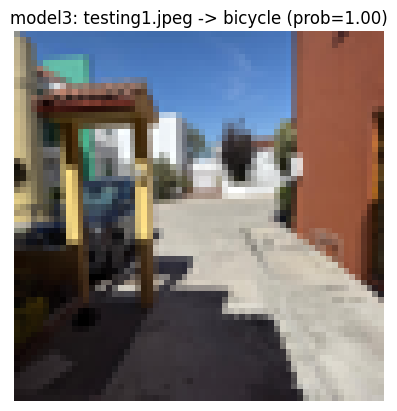

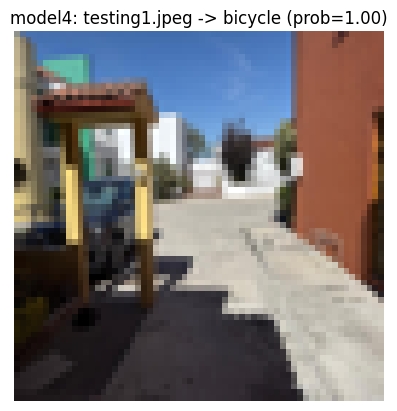

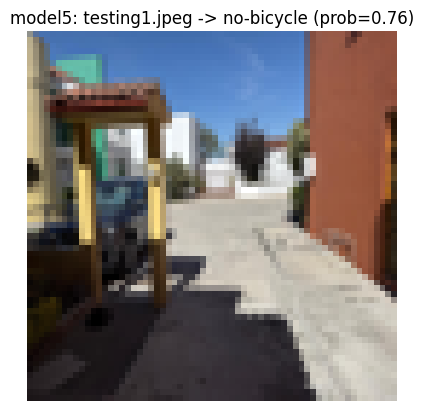

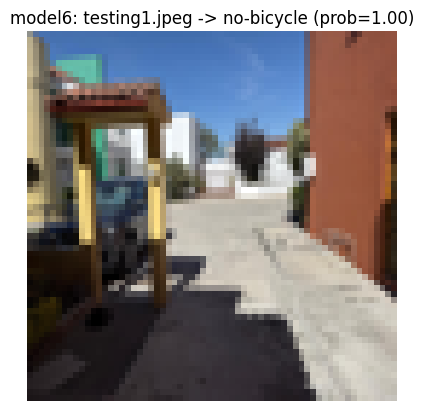

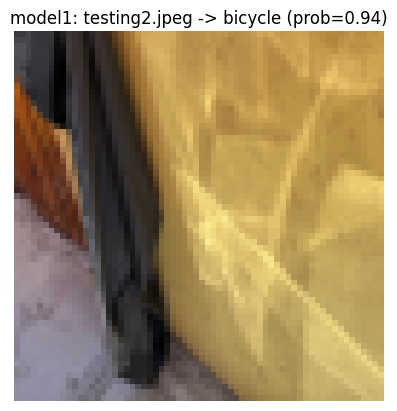

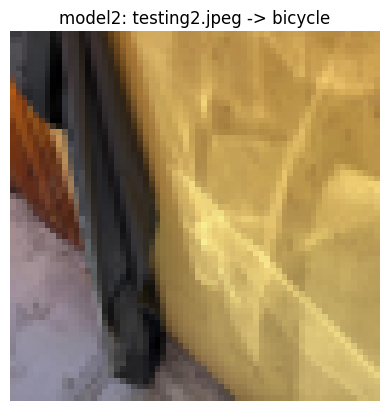

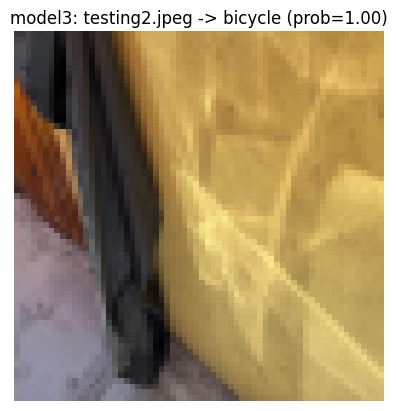

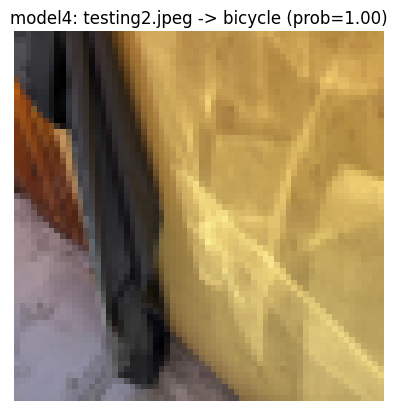

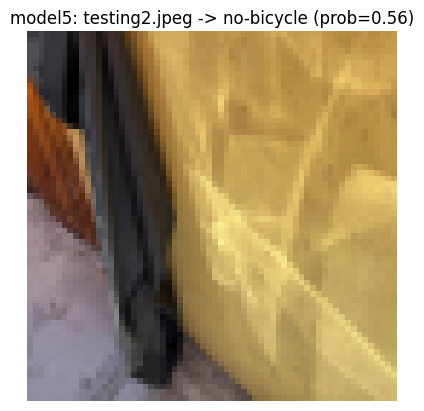

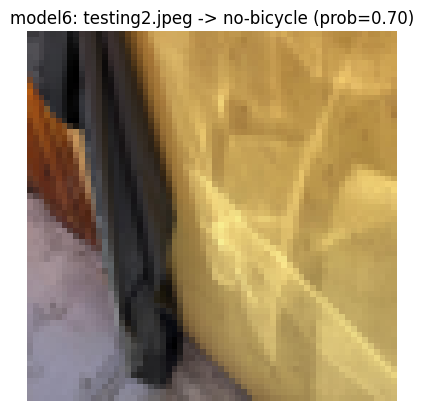

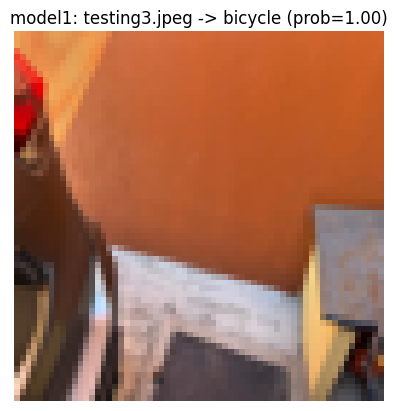

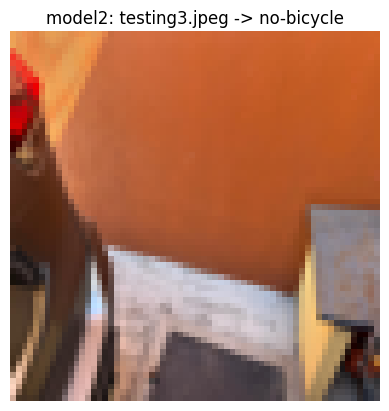

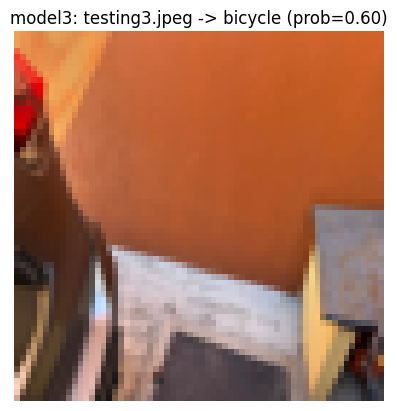

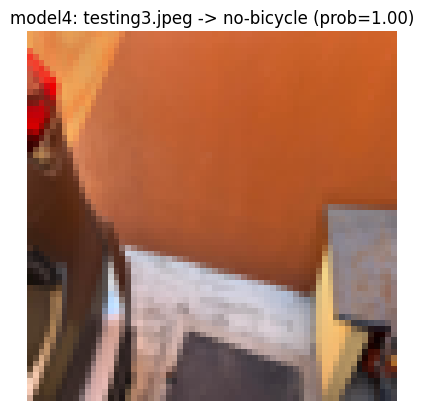

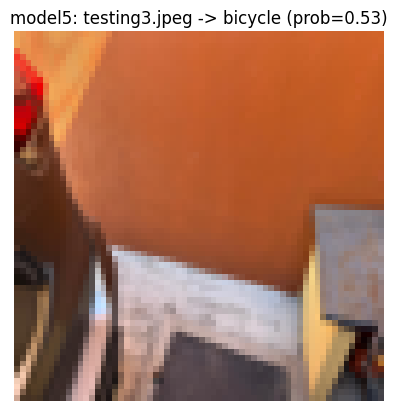

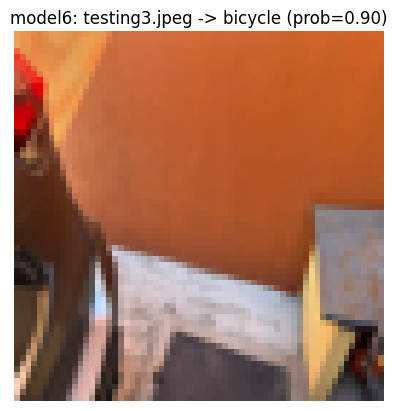

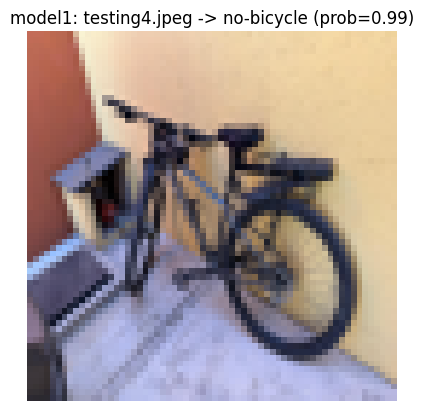

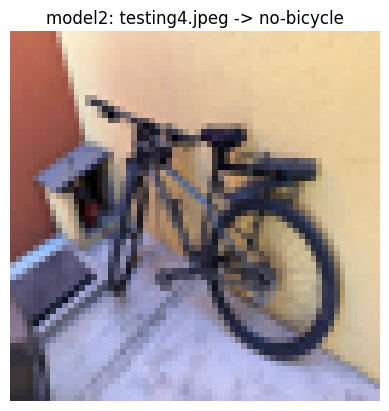

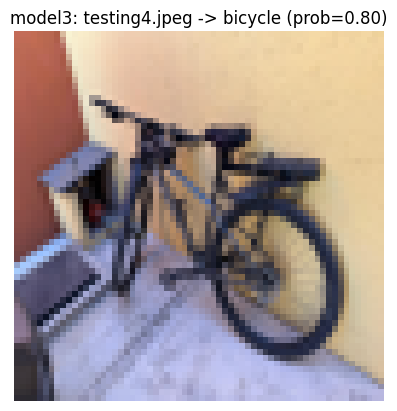

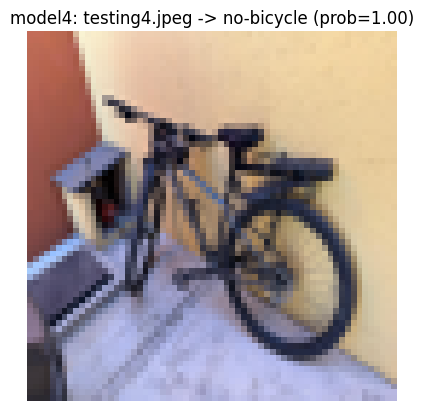

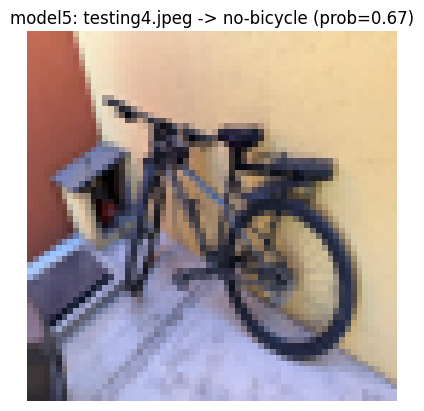

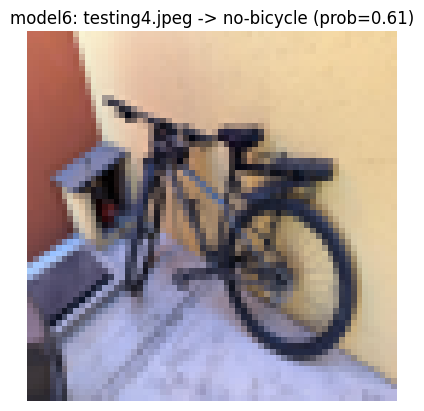

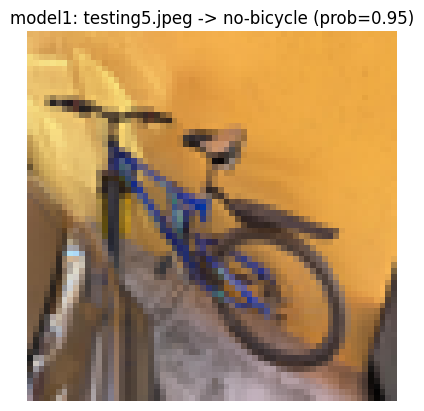

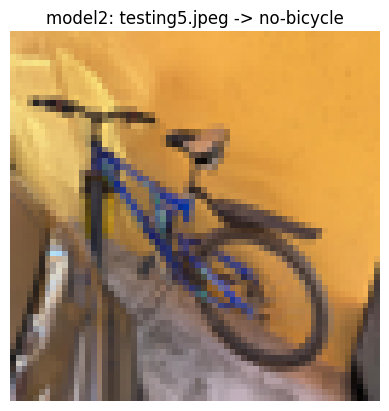

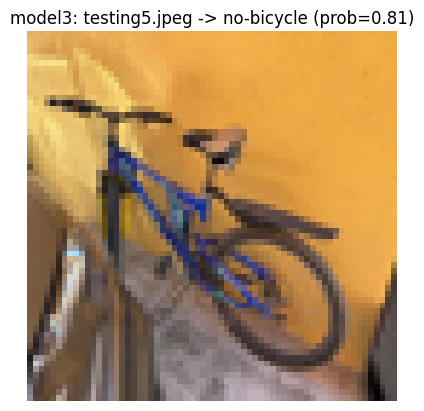

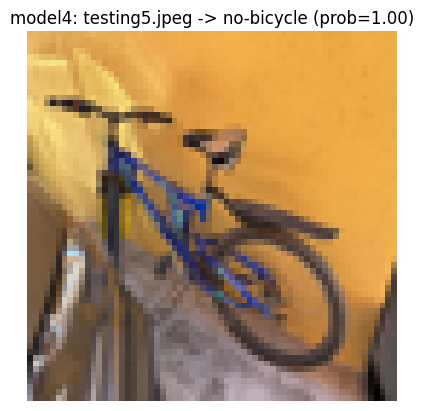

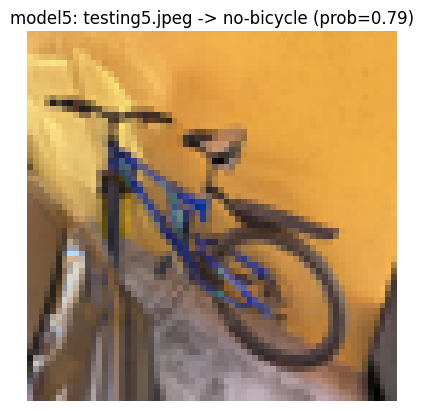

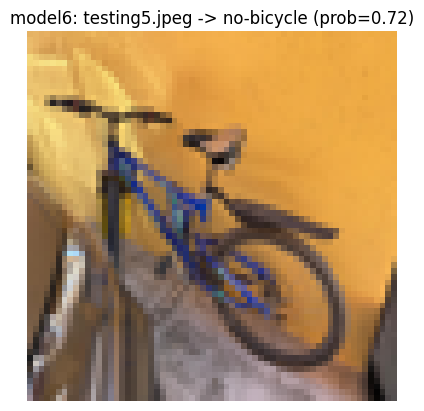

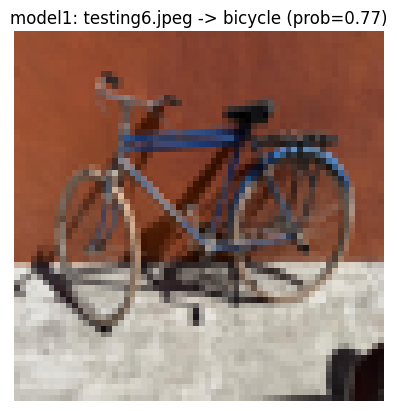

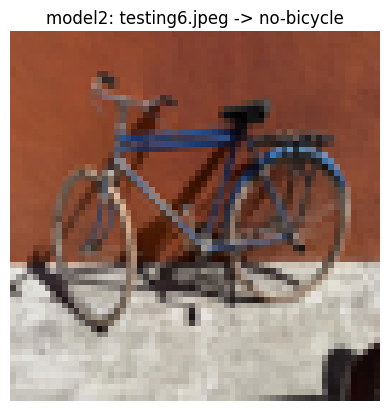

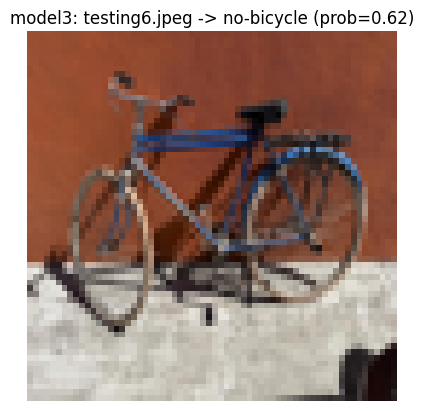

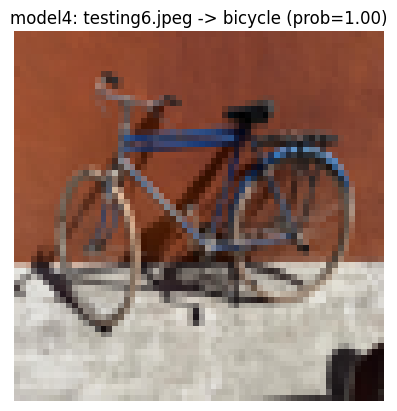

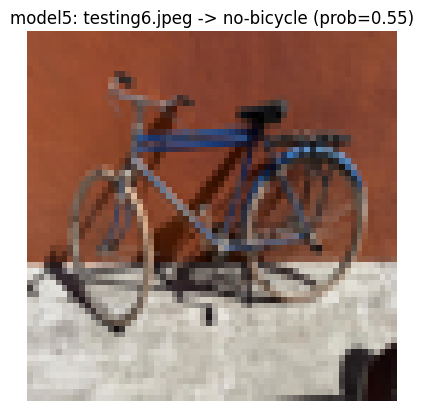

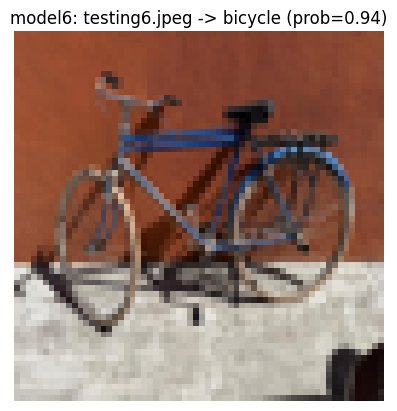

In [86]:
test_imgs_path = "testing_images"
models = [
    ("model1", model1),
    ("model2", model2),
    ("model3", model3),
    ("model4", model4),
    ("model5", model5),
    ("model6", model6),
]

if os.path.isdir(test_imgs_path):
    for fname in sorted(os.listdir(test_imgs_path)):
        test_img_path = os.path.join(test_imgs_path, fname)
        if not os.path.isfile(test_img_path):
            continue
        try:
            img = Image.open(test_img_path).convert("RGB")
            img = img.resize(img_size)
            arr = np.array(img).flatten() / 255.0

            for mname, mdl in models:
                if hasattr(mdl, "predict_proba"):
                    pred_prob = mdl.predict_proba([arr])[0]
                    pred_class = int(mdl.predict([arr])[0])
                    title = f"{mname}: {fname} -> {classes[pred_class]} (prob={pred_prob[pred_class]:.2f})"
                else:
                    pred_class = int(mdl.predict([arr])[0])
                    title = f"{mname}: {fname} -> {classes[pred_class]}"

                plt.imshow(img)
                plt.axis("off")
                plt.title(title)
                plt.show()
        except Exception as e:
            print(f"Error processing test image: {test_img_path} - Error: {e}")
else:
    print(f"Directory not found: {test_imgs_path}")
